##**UNITED STATES TOP 50 PLAYLIST PERFORMANCE AND SONG POPULARITY TREND ANALYSIS**

### > SIYA PANGAM



#Introduction and Analytical Framework

Streaming platforms have redefined how music success is measured, with playlists like Spotify’s “United States Top 50” reflecting real-time listener preferences. Song rankings change rapidly, influenced by engagement, trends, and promotional activity.

For record labels, understanding not just peak performance but sustained chart presence is critical for driving long-term visibility and revenue.

This project presents a historical analysis of the US Top 50 playlist to examine how songs perform over time. To structure the analysis, a set of key performance indicators (KPIs) is defined, including Days on Chart, Average Rank, Rank Volatility Index, Popularity Score Trend, Artist Dominance Index, and Explicit Content Share.

These metrics form the analytical framework used to identify patterns in song success and support data-driven decisions in promotion, release strategy, and content planning.

#Problem Statement

While Top 50 rankings reflect real-time popularity, the underlying patterns of sustained performance, ranking behavior, and artist influence remain unclear. This project focuses on analyzing historical playlist data to uncover these patterns using defined performance metrics.

#Data Ingestion and Validation

Daily Top 50 playlist data is loaded and validated to ensure quality. This includes verifying rank ranges (1–50), handling missing or duplicate records, and standardizing artist names for consistency.

In [1]:
#Importing Libraries
import pandas as pd
import os as os
from os import path
from enum import KEEP

In [2]:
print(os.getcwd())

c:\Users\User\Desktop\GitHubFiles\US-top50-playlist-analysis


In [3]:
#Loading Dataset
df = pd.read_csv(r"C:\Users\User\Desktop\GitHubFiles\US-top50-playlist-analysis\data\Atlantic_United_States.csv")
df.head()


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [4]:
#Basic Structure Check
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


,position,popularity,duration_ms,total_tracks
count,27800.000000,27800.000000,27800.000000,27800.000000
mean,25.500000,87.665612,198635.820180,12.945000
std,14.431129,10.463848,48057.863668,9.457927
min,1.000000,0.000000,37314.000000,1.000000
25%,13.000000,85.000000,166453.000000,2.000000
50%,25.500000,89.000000,189386.000000,14.000000
75%,38.000000,93.000000,228013.000000,18.000000
max,50.000000,100.000000,740010.000000,119.000000


In [5]:
#Missing Values Check
df.isnull().sum()

date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

In [6]:
#Duplicate Check
duplicates = df.duplicated(subset =['date', 'song'])
print("Duplicates:", duplicates.sum())

Duplicates: 50


In [7]:
# Re-calculate 'duplicates'
duplicates = df.duplicated(subset=['date', 'song'], keep=False)

# Filter the DataFrame to show all rows that are part of a duplicate set
duplicates_df = df[duplicates]

duplicates_df.sort_values(by=['date', 'song'])
duplicates_df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
8362,01-11-2024,13,Ghostbusters,Various Artists,78,245253,compilation,14,False,https://i.scdn.co/image/ab67616d0000b273aed480...
8375,01-11-2024,26,Ghostbusters,Ray Parker Jr.,75,239133,compilation,14,False,https://i.scdn.co/image/ab67616d0000b273841c8f...
11069,25-12-2024,20,Christmas (Baby Please Come Home),Darlene Love,85,166453,album,15,False,https://i.scdn.co/image/ab67616d0000b2734bd425...
11096,25-12-2024,47,Christmas (Baby Please Come Home),Mariah Carey,88,153240,album,10,False,https://i.scdn.co/image/ab67616d0000b2734246e3...
14350,01-03-2025,1,CARNIVAL,¥$ & Kanye West & Ty Dolla $ign,94,264324,album,16,True,https://i.scdn.co/image/ab67616d0000b2730a31b4...


In [8]:
#Drop Duplicates
df=df.drop_duplicates(subset=['date', 'song'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27750 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27750 non-null  object
 1   position         27750 non-null  int64 
 2   song             27750 non-null  object
 3   artist           27750 non-null  object
 4   popularity       27750 non-null  int64 
 5   duration_ms      27750 non-null  int64 
 6   album_type       27750 non-null  object
 7   total_tracks     27750 non-null  int64 
 8   is_explicit      27750 non-null  bool  
 9   album_cover_url  27750 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 2.1+ MB


In [9]:
#Rank Validation
invalid_ranks= df[(df['position']<1) | (df['position']>50)]
print("Invalid Ranks:", len(invalid_ranks))

Invalid Ranks: 0


In [10]:
#Standardize artist names
df['artist'] = df['artist'].str.lower().str.strip()
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,eslabon armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,morgan wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),lil durk & j. cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,grupo frontera & bad bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,sza,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [11]:
#Standardize Song Name
df['song'] = df['song'].str.lower().str.strip()
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,ella baila sola,eslabon armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,last night,morgan wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,all my life (feat. j. cole),lil durk & j. cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,grupo frontera & bad bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,kill bill,sza,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


#KPIs / Analytical Framework


To evaluate playlist performance systematically, the following key performance indicators (KPIs) were defined:

**1. Days on Chart (Longevity)**
Measures the total duration a song remains in the Top 50.
**Formula:**
Days on Chart = Count of unique dates per song

**2. Average Rank (Overall Performance)**
Represents the average chart position of a song across its lifecycle.
**Formula:**
Average Rank = Mean(rank)

**3. Best Rank Achieved (Peak Performance)**
Captures the highest position reached by a song.
**Formula:**
Best Rank = Minimum(rank)

**4. Rank Volatility Index (Stability)**
Measures the consistency of a song’s chart position over time.
**Formula:**
Rank Volatility = Standard Deviation(rank)

**5. Popularity Trend Score (Engagement Dynamics)**
Captures short-term momentum using a rolling average of popularity.
**Formula:**
Popularity Trend = Rolling Mean(popularity, window = 7 days)

**6. Artist Dominance Index (Market Presence)**
Quantifies an artist’s overall impact on the playlist by combining output and chart presence.
**Formula:**
Artist Dominance Index = Number of Unique Songs × Total Days on Chart

**7. Entry Rank & Exit Rank (Lifecycle Metrics)**
Tracks the starting and ending positions of a song on the chart.
**Formula:**
Entry Rank = First(rank)
Exit Rank = Last(rank)

**8. Net Rise (Momentum Indicator)**
Measures improvement in rank from entry to peak.
**Formula:**
Net Rise = Entry Rank − Best Rank

**9. Net Decline (Decay Indicator)**
Measures drop in rank from peak to exit.
**Formula:**
Net Decline = Exit Rank − Best Rank

**10. Duration (Content Attribute)**
Represents track length in minutes for content-based analysis.
**Formula:**
Duration (minutes) = Duration (ms) ÷ 60000


#Feature Engineering

Additional features were created to support analysis. A unique song identifier was generated for time-based tracking, and artist names were standardized to extract primary artists while preserving collaborations at the track level.

Key metrics derived include Days on Chart, Average Rank, Best Rank, Rank Volatility Index, Popularity Trend Score, and track duration (in minutes).

In [12]:
#Importing Required Libraries
import numpy as np

In [13]:
#Unique Identifiers & Artist Cleaning
df['song_id'] = df['song'] + '_' + df['artist']
df['primary_artist'] = df['artist'].str.replace(r'feat\..*', '', regex=True)

df[['song_id', 'primary_artist']].head()

,song_id,primary_artist
0,ella baila sola_eslabon armado,eslabon armado
1,last night_morgan wallen,morgan wallen
2,all my life (feat. j. cole)_lil durk & j. cole,lil durk & j. cole
3,un x100to_grupo frontera & bad bunny,grupo frontera & bad bunny
4,kill bill_sza,sza


In [14]:
# Days on the Chart - Longetivity
days_on_chart = df.groupby('song_id')['date'].nunique().reset_index(name='days_on_chart')

In [15]:
#Average Rank
avg_rank = df.groupby('song_id')['position'].mean().reset_index(name='avg_rank')

In [16]:
#Best Rank
best_rank = df.groupby('song_id')['position'].min().reset_index(name='best_rank')

In [17]:
#Rank Volatility index
rank_volatility = df.groupby('song_id')['position'].std().reset_index(name='rank_volatility')

In [18]:
#Duration in Minutes
df['duration_minutes'] = df['duration_ms'] / 60000

In [19]:
#Popularity Trend Song - Rolling Avg
df = df.sort_values(by=['date', 'song_id'])
df['popularity_trend'] = df.groupby('song_id')['popularity'].rolling(window=7, min_periods=1).mean().reset_index(0, drop=True)

In [20]:
#Combining all metrics
features = days_on_chart.merge(avg_rank, on='song_id', how='left').merge(best_rank, on='song_id', how='left').merge(rank_volatility, on='song_id', how='left')

In [21]:
#popularity trend - latest value per song
popularity_trend = df.sort_values(by='date').groupby('song_id').tail(1)[['song_id', 'popularity_trend']]
popularity_trend['song_id'].duplicated().sum()

np.int64(0)

In [22]:
#Preparing Meta data
meta = df[['song_id', 'song', 'primary_artist', 'duration_minutes']].drop_duplicates(subset='song_id')

In [23]:
#Preparing analysis data set
analysis_df = (features.merge(popularity_trend, on='song_id', how='left').merge(meta, on='song_id', how='left'))
analysis_df.head()

,song_id,days_on_chart,avg_rank,best_rank,rank_volatility,popularity_trend,song,primary_artist,duration_minutes
0,"""slut!"" (taylor's version) (from the vault)_ta...",26,15.500000,3,12.130128,76.285714,"""slut!"" (taylor's version) (from the vault)",taylor swift,3.006350
1,(don't fear) the reaper_blue öyster cult,1,50.000000,50,NaN,77.000000,(don't fear) the reaper,blue öyster cult,5.135333
2,(there's no place like) home for the holidays ...,2,45.000000,45,0.000000,70.000000,(there's no place like) home for the holidays ...,perry como,2.931550
3,16 carriages_beyoncé,10,26.000000,16,10.635371,68.285714,16 carriages,beyoncé,3.787500
4,2 hands_tate mcrae,7,33.571429,8,12.286268,76.571429,2 hands,tate mcrae,3.030333


In [24]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_id           972 non-null    object 
 1   days_on_chart     972 non-null    int64  
 2   avg_rank          972 non-null    float64
 3   best_rank         972 non-null    int64  
 4   rank_volatility   817 non-null    float64
 5   popularity_trend  972 non-null    float64
 6   song              972 non-null    object 
 7   primary_artist    972 non-null    object 
 8   duration_minutes  972 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 68.5+ KB


In [25]:
analysis_df['rank_volatility'] = analysis_df['rank_volatility'].fillna(0)

In [26]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_id           972 non-null    object 
 1   days_on_chart     972 non-null    int64  
 2   avg_rank          972 non-null    float64
 3   best_rank         972 non-null    int64  
 4   rank_volatility   972 non-null    float64
 5   popularity_trend  972 non-null    float64
 6   song              972 non-null    object 
 7   primary_artist    972 non-null    object 
 8   duration_minutes  972 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 68.5+ KB


# *Exploratory Data Analysis :*





In [27]:
#Importing required libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Playlist Ranking Analysis
This section analyzes behavior within the Top 50 playlist, focusing on distribution patterns, rank movements, and entry-exit dynamics to understand how songs rise, stabilize, and decline over time.

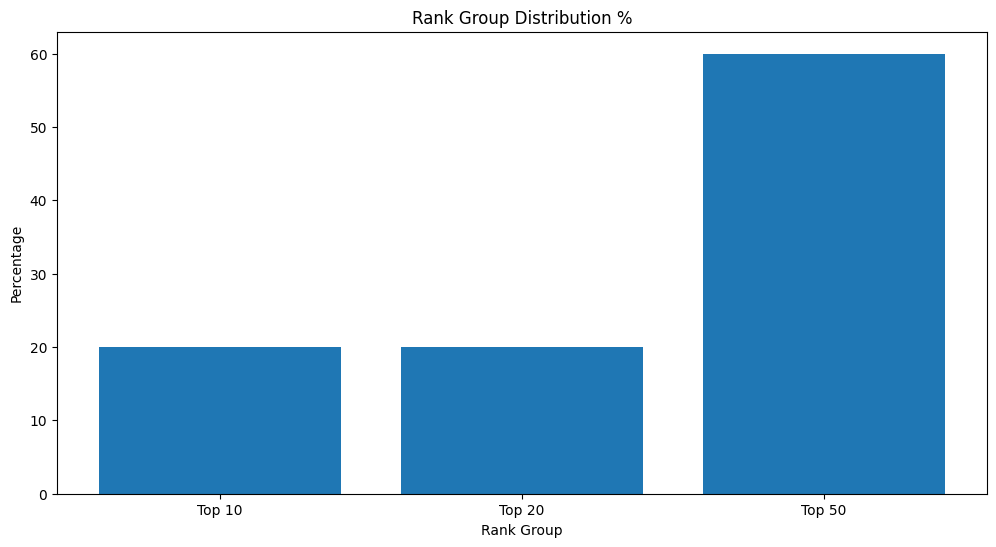

In [28]:
#Daily Rank Distribution
plt.figure(figsize=(12, 6))
df['rank_group']=pd.cut(df['position'], bins=[0,10,20,50], labels=['Top 10','Top 20', 'Top 50'])
rank_counts=(df['rank_group'].value_counts(normalize=True)*100).sort_index()
plt.bar(rank_counts.index.astype(str), rank_counts.values)
plt.title('Rank Group Distribution %')
plt.xlabel('Rank Group')
plt.ylabel('Percentage')
plt.show()

The normalized rank group distribution represents how frequently songs occupy different segments of the playlist across all days.

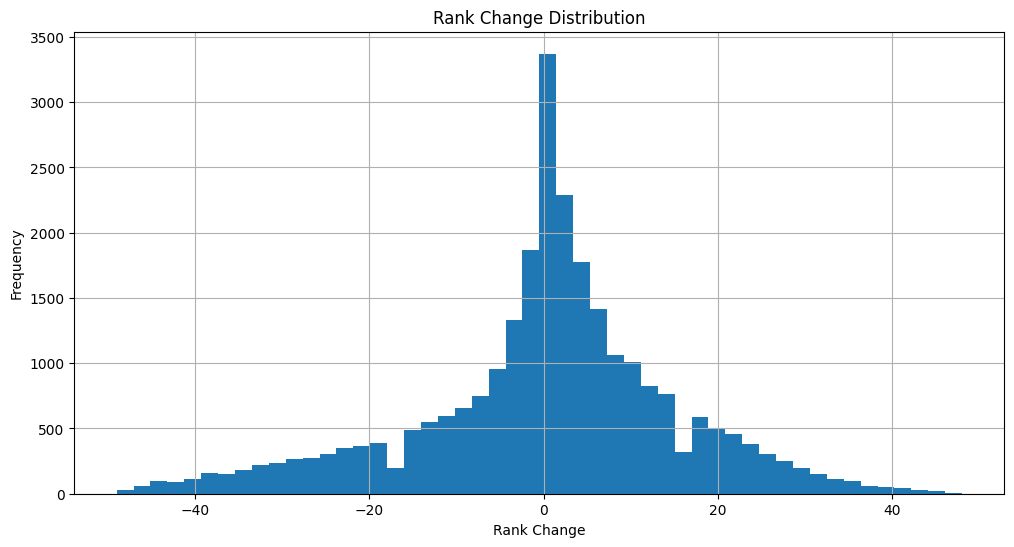

In [29]:
#Rank Movement Patterns
plt.figure(figsize=(12, 6))
df_rankchange= df.sort_values(by=['song_id', 'date'])
df['rank_change']=df_rankchange.groupby('song_id')['position'].diff()
df['rank_change'].hist(bins=50)
plt.title('Rank Change Distribution')
plt.xlabel('Rank Change')
plt.ylabel('Frequency')
plt.show()

The concentration of rank changes around zero indicates that most songs maintain stable positions on a day-to-day basis, with limited fluctuation.

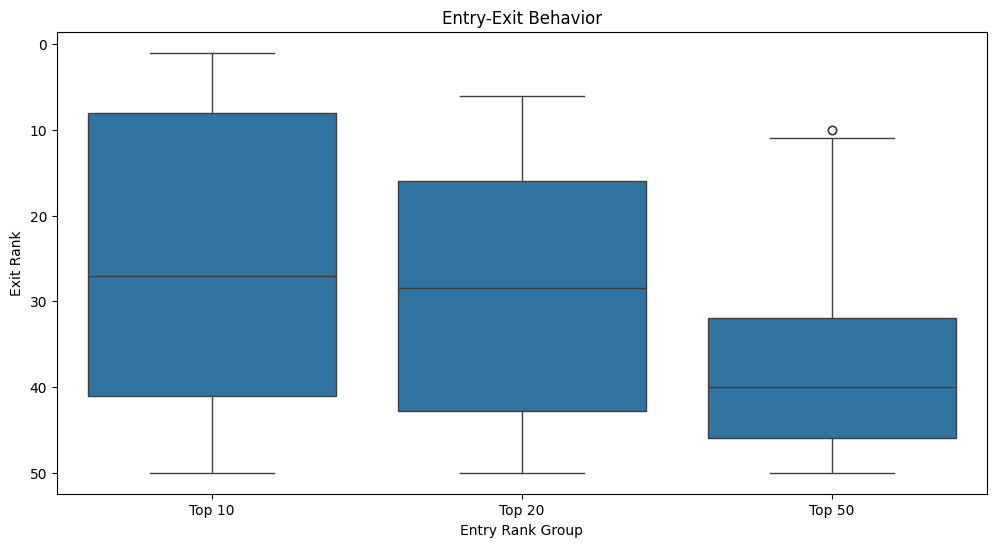

In [30]:
#Entry VS Exit Behavior
plt.figure(figsize=(12, 6))
entry_exit = df.groupby('song').agg({'position':['first', 'last']}).reset_index()
entry_exit.columns = ['song', 'entry_rank', 'exit_rank']
entry_exit['entry_bucket']= pd.cut(entry_exit['entry_rank'], bins=[0,10,20,50], labels=['Top 10','Top 20', 'Top 50'])
sns.boxplot(x='entry_bucket', y='exit_rank', data=entry_exit)
plt.title('Entry-Exit Behavior')
plt.xlabel('Entry Rank Group')
plt.ylabel('Exit Rank')
plt.gca().invert_yaxis()
plt.show()

Songs entering in higher rank brackets tend to exit at better positions, while lower-entry songs exhibit lesser variability and generally poorer exit ranks.

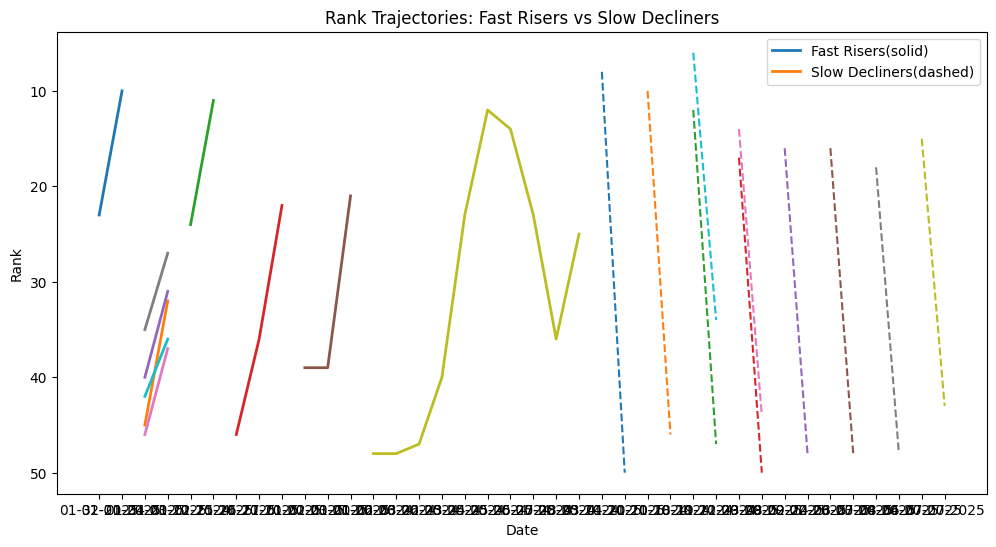

In [31]:
#Fast risers VS Slow decliners
plt.figure(figsize=(12, 6))
rank_movement = df.groupby('song')['rank_change'].mean().reset_index(name='avg_rank_change')
fast_risers = rank_movement.nsmallest(10, 'avg_rank_change')
slow_decliners = rank_movement.nlargest(10, 'avg_rank_change')

# Fast risers (green)
for song_name in fast_risers['song']:
    data = df[df['song'] == song_name]
    plt.plot(data['date'], data['position'], label='Fast Riser', linewidth=2)

# Slow decliners (red)
for song_name in slow_decliners['song']:
    data = df[df['song'] == song_name]
    plt.plot(data['date'], data['position'], linestyle='--', label='Slow Decliner')

plt.gca().invert_yaxis()
plt.xlabel('Date')
plt.ylabel('Rank')
plt.title('Rank Trajectories: Fast Risers vs Slow Decliners')

plt.legend(['Fast Risers(solid)', 'Slow Decliners(dashed)'])
plt.show()

Fast risers exhibit steep upward trajectories, indicating strong momentum and rapid audience adoption, whereas slow decliners display gradual downward trends, suggesting that songs can sustain visibility for extended periods even as popularity declines. This highlights the difference between short-term spikes and long-term retention in playlist performance.

---


Also, Some fast-rising songs (centre curve) exhibit a rise–peak–decline pattern, where initial rapid growth is followed by a drop in rank after reaching peak popularity. This suggests that not all fast risers sustain their momentum, and many transition into a decline phase shortly after peaking.

#Song Level Performance Analysis

This section evaluates individual song performance using key metrics such as chart longevity, popularity, and peak rank. The analysis aims to distinguish between short-term hits and consistently successful tracks based on their behavior over time.

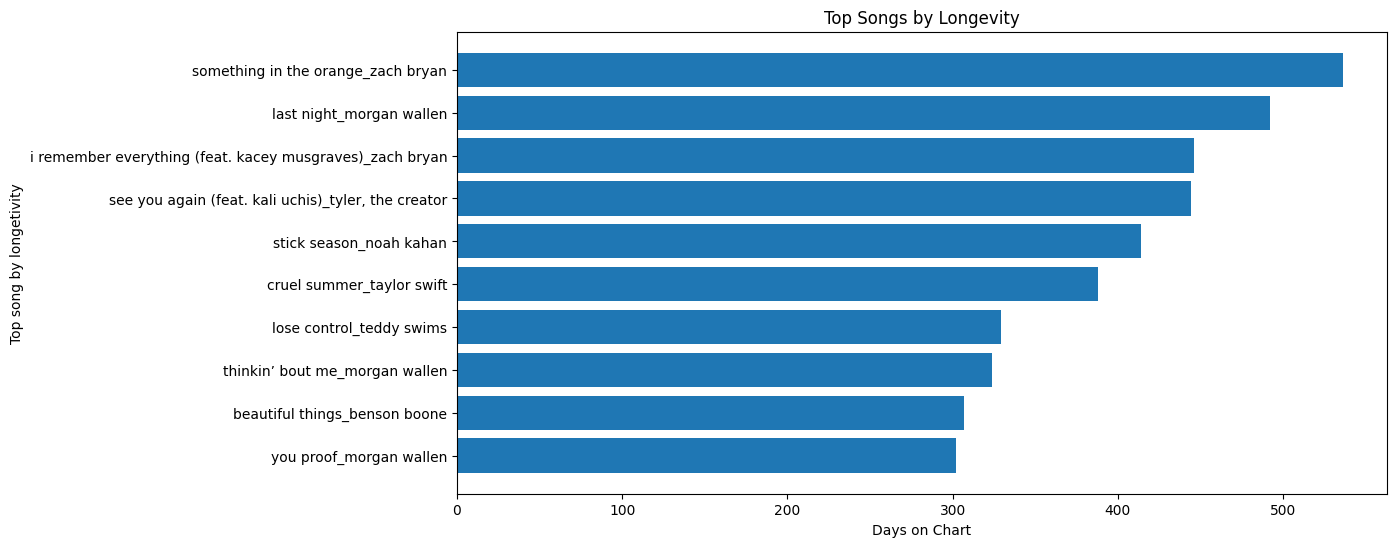

In [32]:
#Songs with Longest Playlist Present
plt.figure(figsize=(12, 6))
top_longevity = analysis_df.sort_values(by='days_on_chart', ascending=False).head(10)
plt.barh(top_longevity['song_id'], top_longevity['days_on_chart'])
plt.xlabel('Days on Chart')
plt.ylabel('Top song by longetivity')
plt.title('Top Songs by Longevity')
plt.gca().invert_yaxis()
plt.show()

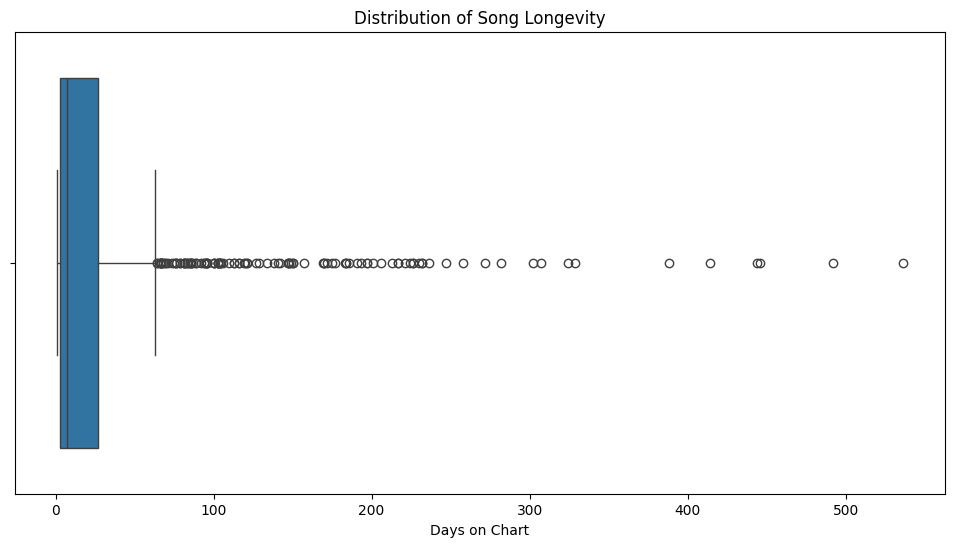

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=analysis_df['days_on_chart'])
plt.xlabel('Days on Chart')
plt.title('Distribution of Song Longevity')
plt.show()

The box plot indicates that while the majority of songs have limited chart presence, a few outliers achieve significantly longer durations, representing highly successful tracks with sustained popularity.

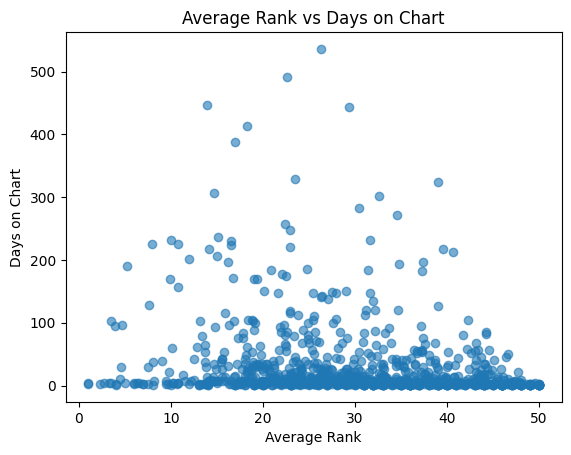

In [34]:
plt.scatter(analysis_df['avg_rank'], analysis_df['days_on_chart'], alpha=0.6)
plt.xlabel('Average Rank')
plt.ylabel('Days on Chart')
plt.title('Average Rank vs Days on Chart')
plt.show()

Songs with longer chart presence generally maintain better average ranks, indicating that sustained visibility is often associated with consistent performance rather than sporadic success.

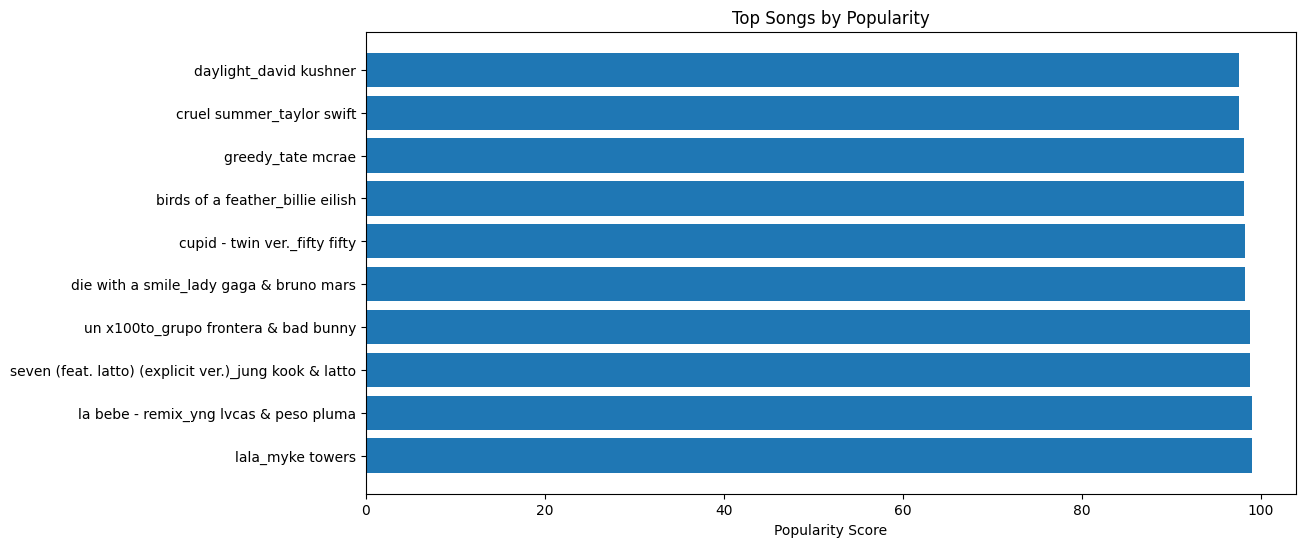

In [35]:
#Songs with Highest Average Popularity
plt.figure(figsize=(12, 6))
top_popularity = analysis_df.sort_values(by='popularity_trend', ascending=False).head(10)
plt.barh(top_popularity['song_id'], top_popularity['popularity_trend'])
plt.xlabel('Popularity Score')
plt.title('Top Songs by Popularity')
plt.show()

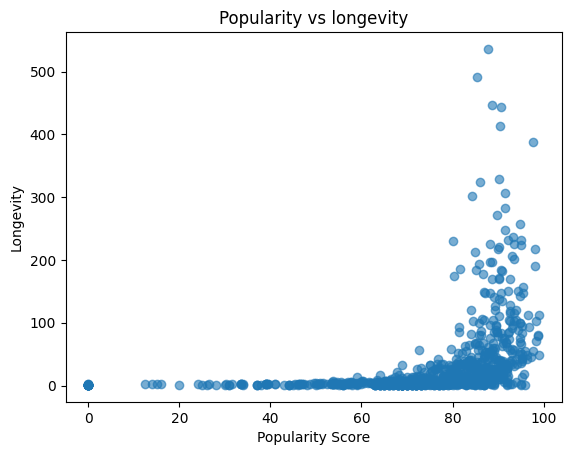

In [36]:
plt.scatter(analysis_df['popularity_trend'], analysis_df['days_on_chart'], alpha=0.6)
plt.xlabel('Popularity Score')
plt.ylabel('Longevity')
plt.title('Popularity vs longevity')
plt.show()

Songs with higher popularity score tend to maintain higher longevity.

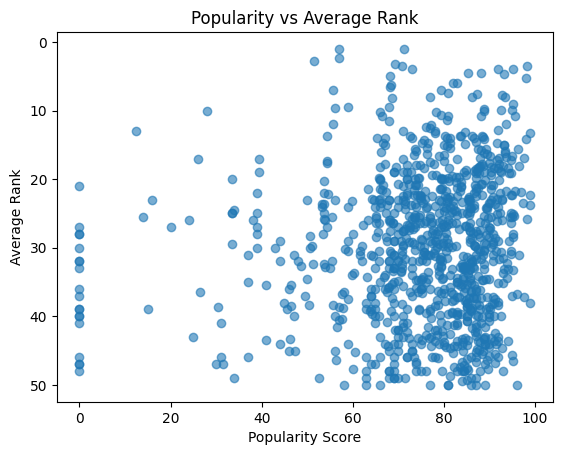

In [37]:
plt.scatter(analysis_df['popularity_trend'], analysis_df['avg_rank'], alpha=0.6)
plt.xlabel('Popularity Score')
plt.ylabel('Average Rank')
plt.title('Popularity vs Average Rank')
plt.gca().invert_yaxis()
plt.show()

There is a general inverse relationship between popularity and average rank.

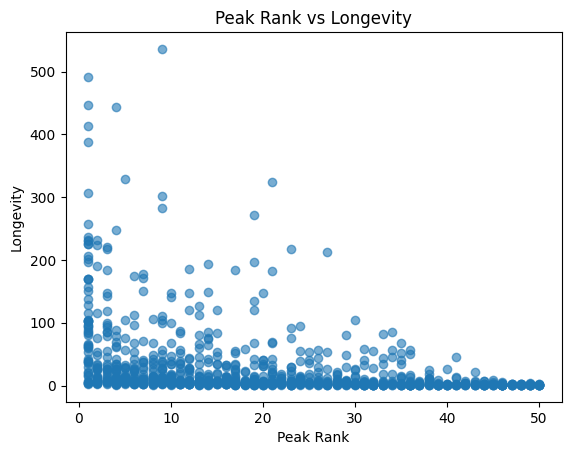

In [38]:
#Peak Rank VS Longevity
plt.scatter(analysis_df['best_rank'], analysis_df['days_on_chart'], alpha=0.6)
plt.xlabel('Peak Rank')
plt.ylabel('Longevity')
plt.title('Peak Rank vs Longevity')
plt.show()

Songs achieving higher peak positions (closer to rank 1) generally tend to stay longer on the chart, indicating a positive relationship between early success and sustained presence. However, some songs with moderate peak ranks still achieve high longevity, suggesting consistent listener engagement without reaching top positions.

#Artist Performance Analysis

This section evaluates artist-level performance based on chart presence, output, and consistency. The analysis focuses on identifying dominant artists and understanding their contribution to playlist dynamics.

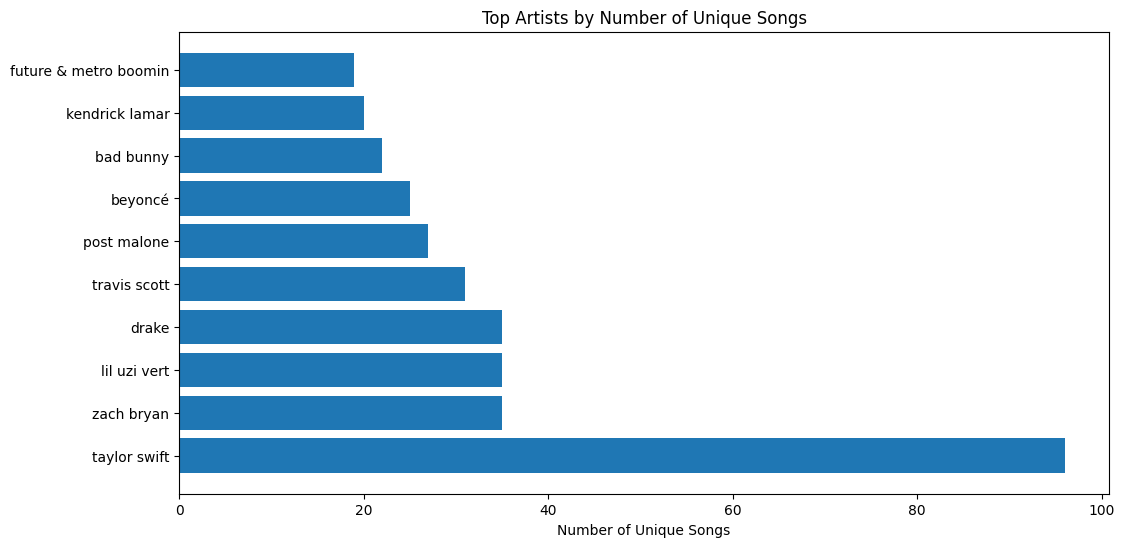

In [39]:
#Number of Unique Songs per Artist
plt.figure(figsize=(12, 6))
unqiue_songs_per_artist = analysis_df.groupby('primary_artist')['song_id'].nunique().reset_index(name='unique_songs')
top_artists = unqiue_songs_per_artist.sort_values(by='unique_songs', ascending=False).head(10)
plt.barh(top_artists['primary_artist'], top_artists['unique_songs'])
plt.xlabel('Number of Unique Songs')
plt.title('Top Artists by Number of Unique Songs')
plt.show()

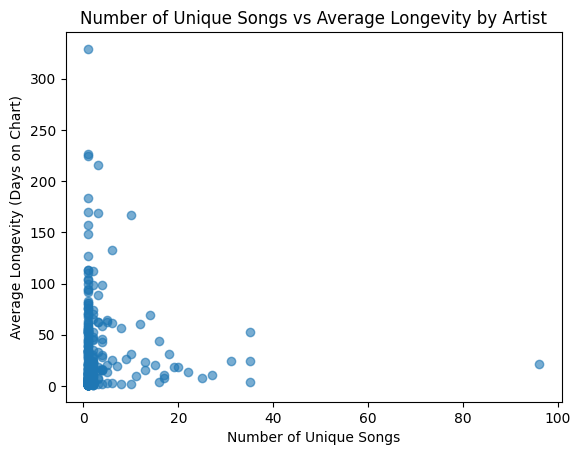

In [40]:
avg_longevity_per_artist = analysis_df.groupby('primary_artist')['days_on_chart'].mean().reset_index(name='avg_longevity')

artist_stats_for_plot = unqiue_songs_per_artist.merge(avg_longevity_per_artist, on='primary_artist', how='left')

plt.scatter(artist_stats_for_plot['unique_songs'], artist_stats_for_plot['avg_longevity'], alpha=0.6)
plt.xlabel('Number of Unique Songs')
plt.ylabel('Average Longevity (Days on Chart)')
plt.title('Number of Unique Songs vs Average Longevity by Artist')
plt.show()

The distribution indicates that most artists contribute a limited number of songs with relatively short chart durations. However, a small group of artists achieves high longevity with fewer tracks, emphasizing the impact of quality over quantity. Additionally, artists with a larger number of songs generally show lower average longevity, suggesting diminishing returns in sustained performance with increased output.

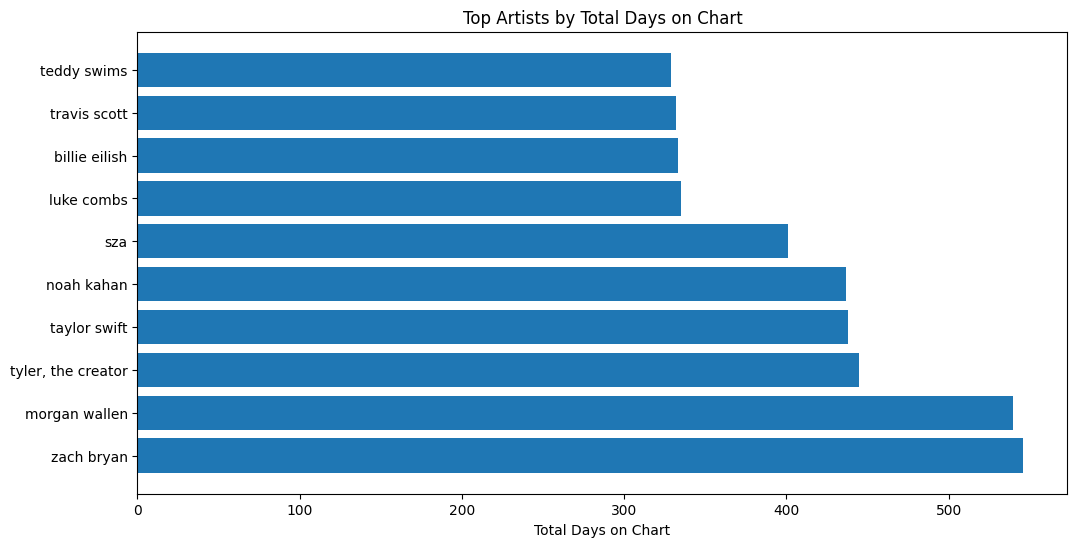

In [41]:
#Total Days Artist Appears on Playlist
plt.figure(figsize=(12, 6))
artist_days= df.groupby('primary_artist')['date'].nunique().reset_index(name='total_days')
top_artists_days = artist_days.sort_values(by='total_days', ascending=False).head(10)
plt.barh(top_artists_days['primary_artist'], top_artists_days['total_days'])
plt.xlabel('Total Days on Chart')
plt.title('Top Artists by Total Days on Chart')
plt.show()

Artists with longer total presence on the playlist maintain sustained visibility, suggesting consistent listener engagement and stronger brand recall compared to artists with short-lived appearances.

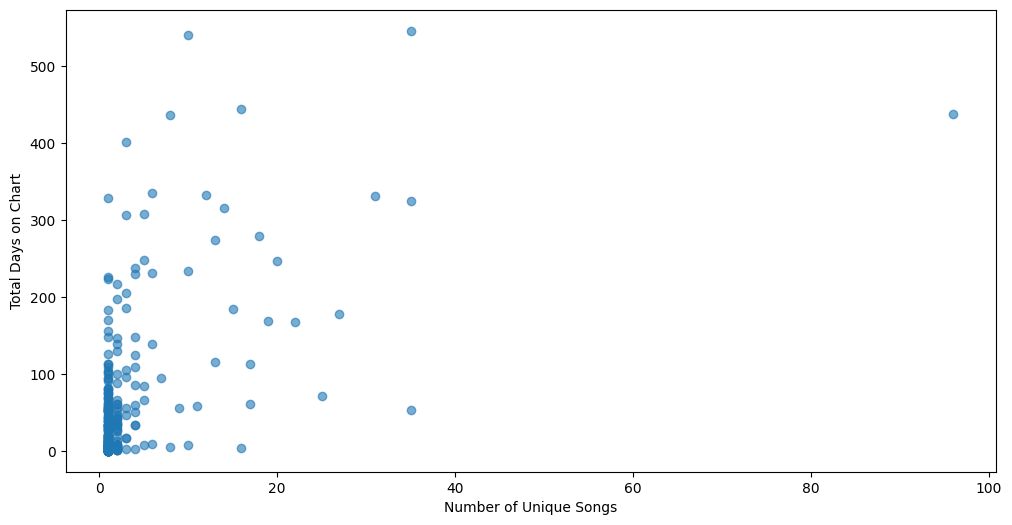

In [42]:
#Artist Dominace
plt.figure(figsize=(12, 6))
artist_performance = unqiue_songs_per_artist.merge(artist_days , on='primary_artist', how='left')
plt.scatter(artist_performance['unique_songs'], artist_performance['total_days'], alpha=0.6)
plt.xlabel('Number of Unique Songs')
plt.ylabel('Total Days on Chart')
plt.show()

The relationship between the number of songs and total chart presence highlights different artist strategies. Some artists dominate through frequent releases, while others achieve long-lasting presence with fewer but highly successful tracks.

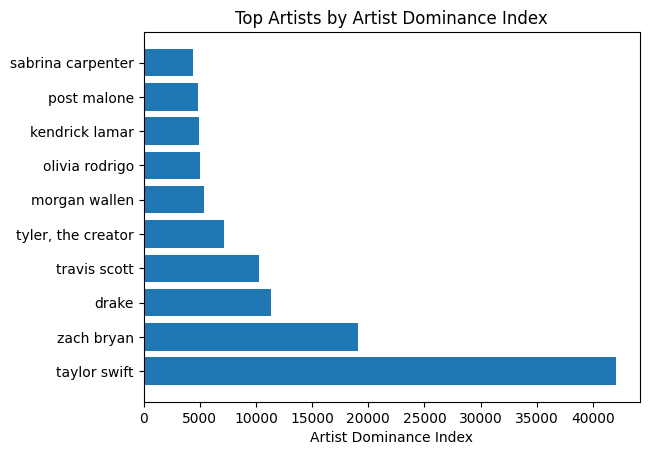

In [43]:
#Artist Dominance Index
artist_songs= analysis_df.groupby('primary_artist')['song_id'].nunique().reset_index(name='unique_songs')
artist_days= df.groupby('primary_artist')['date'].nunique().reset_index(name='total_days')
artist_dominance= artist_songs.merge(artist_days, on='primary_artist', how='left')
artist_dominance['ADI']= artist_dominance['unique_songs']*artist_dominance['total_days']
top_dominant_artists = artist_dominance.sort_values(by='ADI', ascending=False).head(10)
plt.barh(top_dominant_artists['primary_artist'], top_dominant_artists['ADI'])
plt.xlabel('Artist Dominance Index')
plt.title('Top Artists by Artist Dominance Index')
plt.show()

#Popularity Score Analytics

This section examines the relationship between popularity scores and chart performance, focusing on how listener engagement translates into ranking behavior and stability.

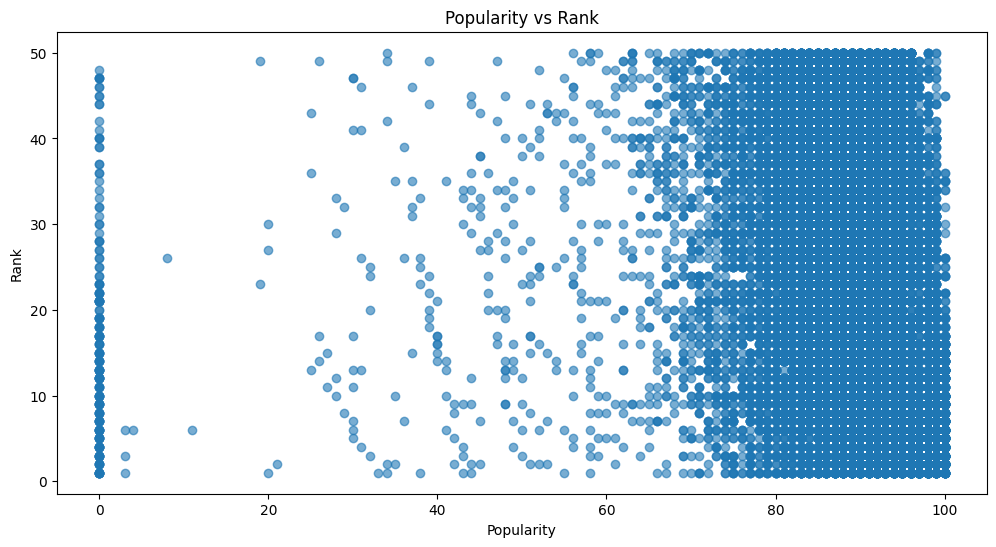

In [44]:
#Popularity vs Rank Correlation
plt.figure(figsize=(12, 6))
plt.scatter(df['popularity'], df['position'], alpha=0.6)
plt.xlabel('Popularity')
plt.ylabel('Rank')
plt.title('Popularity vs Rank')
plt.show()

Most on the songs on chart have high popularity whereas there are certain outliers which are short lived but gain higher ranks at the time.

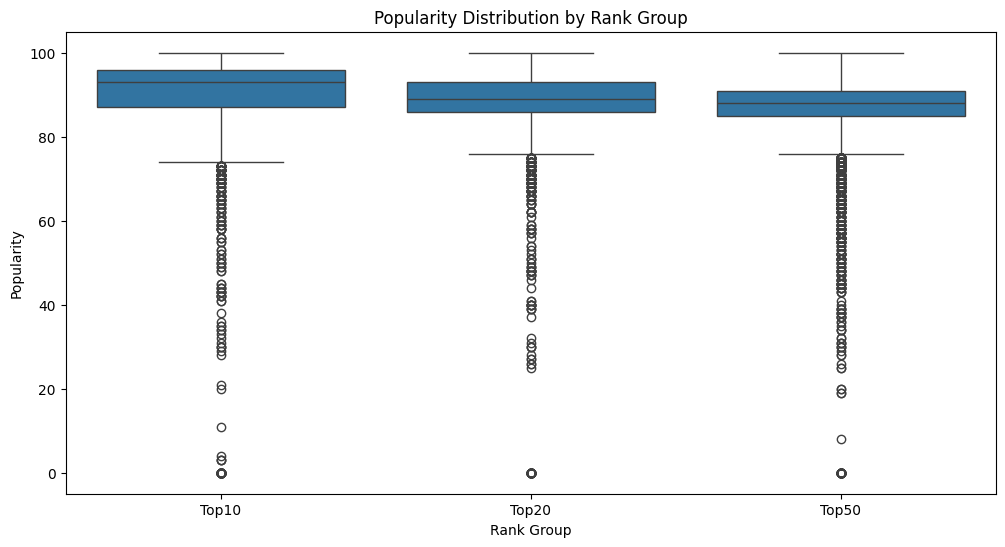

In [45]:
#Popularity Distribution by Rank Buckets
df['rank_group']=pd.cut(df['position'], bins=[0,10,20,50], labels=['Top10', 'Top20', 'Top50'])
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['rank_group'], y=df['popularity'])
plt.xlabel('Rank Group')
plt.ylabel('Popularity')
plt.title('Popularity Distribution by Rank Group')
plt.show()

Songs in the Top 10 exhibit higher and more consistent popularity scores compared to lower rank groups. As rank decreases, the variability in popularity increases, indicating less consistent listener engagement among lower-ranked songs.

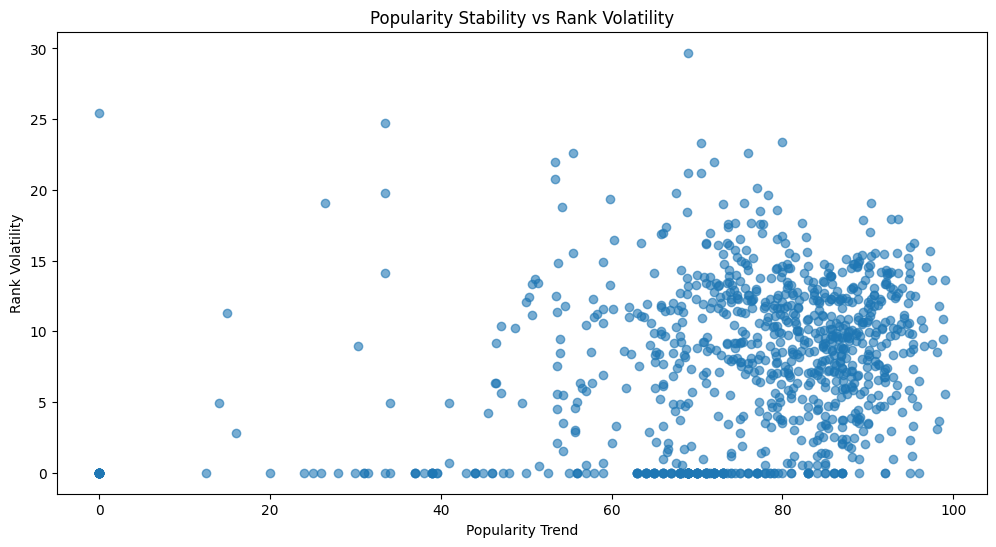

In [46]:
#Popularity Stability vs Rank Volatility
plt.figure(figsize=(12, 6))
plt.scatter(analysis_df['popularity_trend'], analysis_df['rank_volatility'], alpha=0.6)
plt.xlabel('Popularity Trend')
plt.ylabel('Rank Volatility')
plt.title('Popularity Stability vs Rank Volatility')
plt.show()

Songs with higher and more stable popularity tend to exhibit lower rank volatility, indicating consistent chart positions. In contrast, songs with fluctuating popularity show higher volatility, reflecting unstable performance and short-lived chart presence.

In [47]:
#Popularity-Rank Correlation
correlation = df[['popularity', 'position']].corr(method='pearson')
print(correlation)

            popularity  position
popularity    1.000000 -0.094449
position     -0.094449  1.000000


The correlation value further quantifies the inverse relationship between popularity and rank, reinforcing the observed trend.

#Content Attribute Analysis

This section analyzes how song characteristics such as explicit content, release type, duration, and album size influence popularity and chart performance.

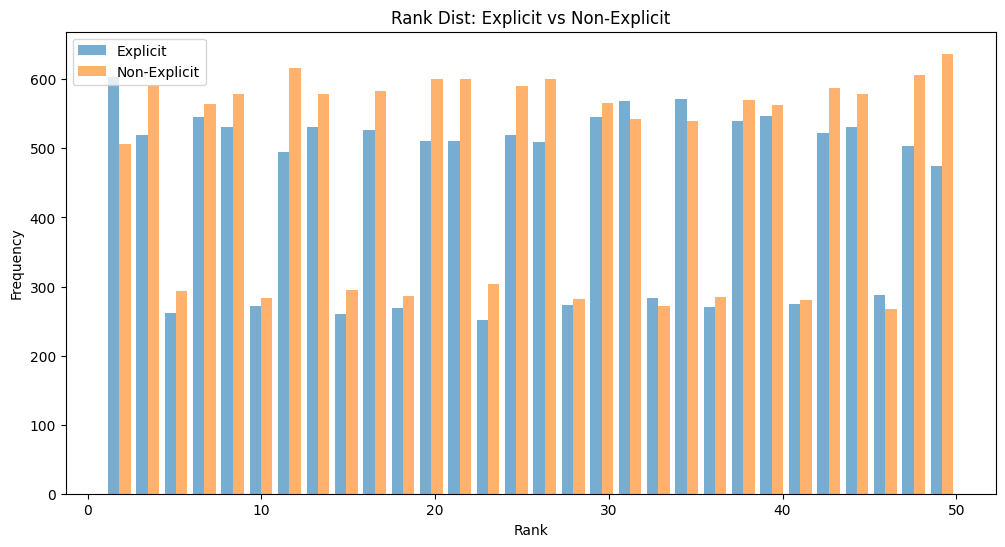

In [48]:
#Explicit vs Non-Explicit Song Performance
plt.figure(figsize=(12, 6))
plt.hist([df[df['is_explicit'] == True]['position'], df[df['is_explicit'] == False]['position']], bins=30, alpha=0.6, label=['Explicit', 'Non-Explicit'])
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Rank Dist: Explicit vs Non-Explicit')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Explicit vs Non-Explicit')

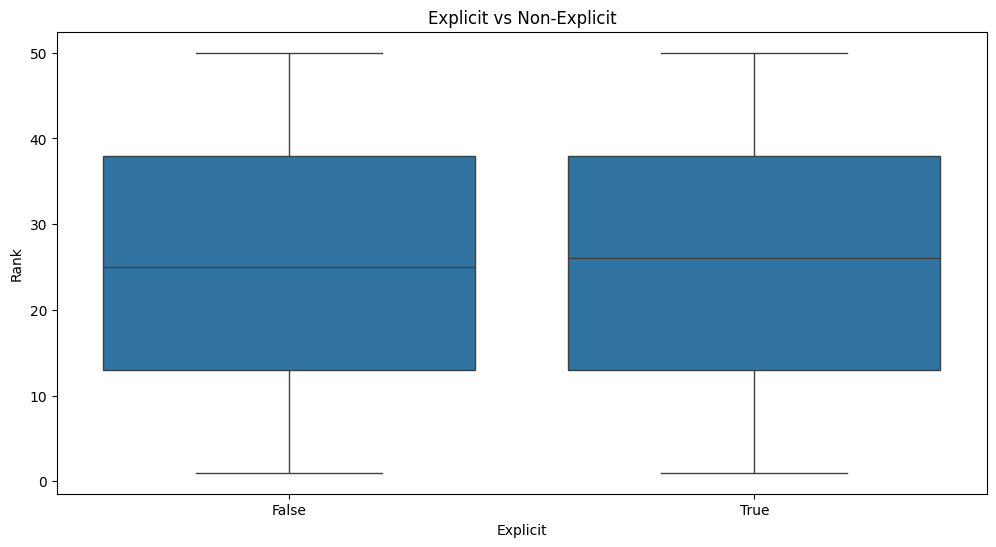

In [49]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['is_explicit'], y=df['position'])
plt.xlabel('Explicit')
plt.ylabel('Rank')
plt.title('Explicit vs Non-Explicit')

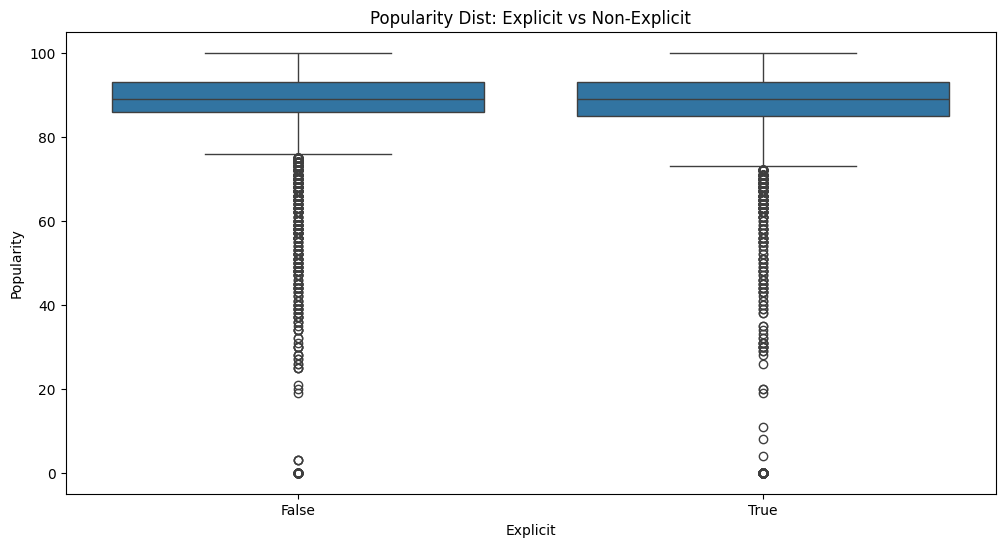

In [50]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['is_explicit'], y=df['popularity'])
plt.xlabel('Explicit')
plt.ylabel('Popularity')
plt.title('Popularity Dist: Explicit vs Non-Explicit')
plt.show()

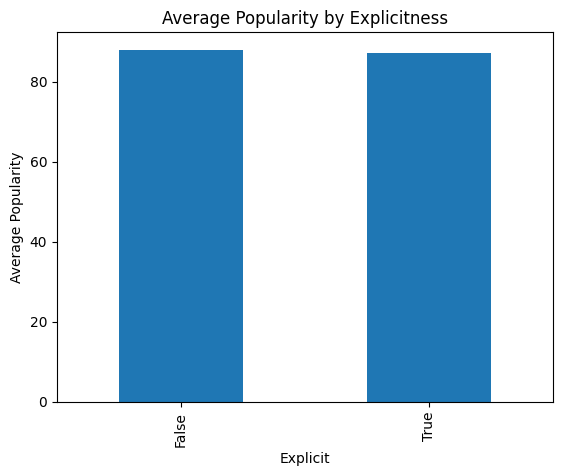

In [51]:
explicit_avg = df.groupby('is_explicit')['popularity'].mean()
explicit_avg.plot(kind='bar')
plt.title('Average Popularity by Explicitness')
plt.xlabel('Explicit')
plt.ylabel('Average Popularity')
plt.show()

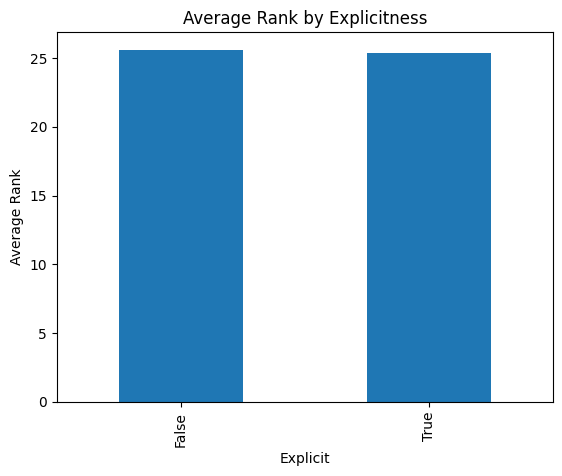

In [52]:
explicit_avg = df.groupby('is_explicit')['position'].mean()
explicit_avg.plot(kind='bar')
plt.title('Average Rank by Explicitness')
plt.xlabel('Explicit')
plt.ylabel('Average Rank')
plt.show()

The analysis indicates that explicit content does not have a significant impact on chart performance and popularity, suggesting that listener engagement is driven more by musical and promotional factors than content classification.

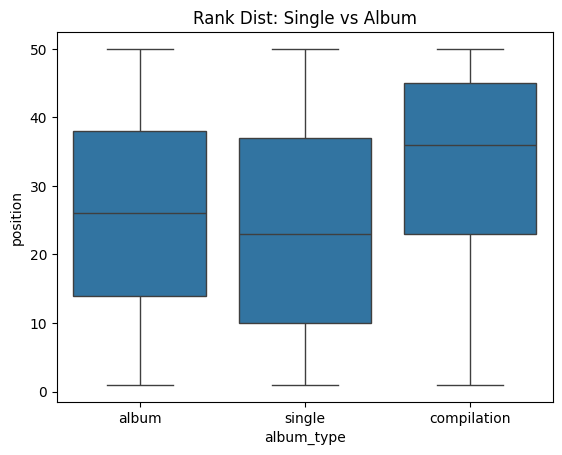

In [53]:
#Single vs Album Track Comparison
sns.boxplot(x='album_type', y='position', data=df)
plt.title('Rank Dist: Single vs Album')
plt.show()

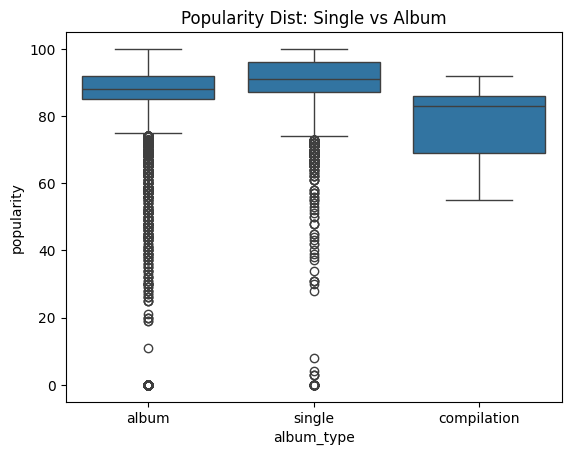

In [54]:
sns.boxplot(x='album_type', y='popularity', data=df)
plt.title('Popularity Dist: Single vs Album')
plt.show()

While singles achieve better chart positions, compilation tracks exhibit relatively high popularity scores but do not translate this into strong rankings. This indicates a disconnect between listener engagement and chart performance, where compilation songs may have steady but less competitive streams compared to singles that benefit from stronger promotion and initial traction.


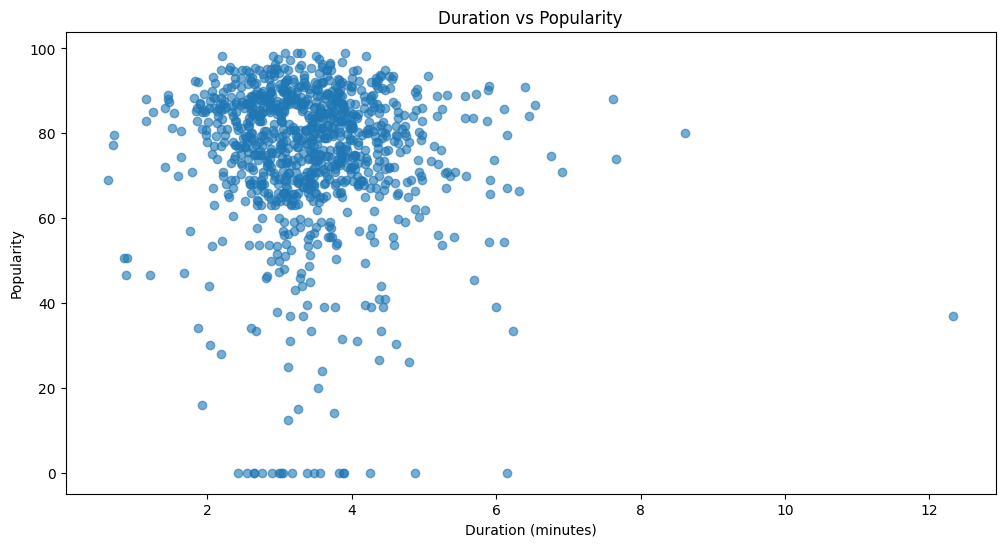

In [55]:
#Song Duration vs Popularity
plt.figure(figsize=(12, 6))
plt.scatter(analysis_df['duration_minutes'], analysis_df['popularity_trend'], alpha=0.6)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.title('Duration vs Popularity')
plt.show()

There is a strong concentration of high-popularity songs within the 2–4 minute duration range, suggesting this as the optimal length for listener engagement. Songs outside this range exhibit more variability. This highlights the importance of aligning track length with listener consumption patterns in the streaming era.

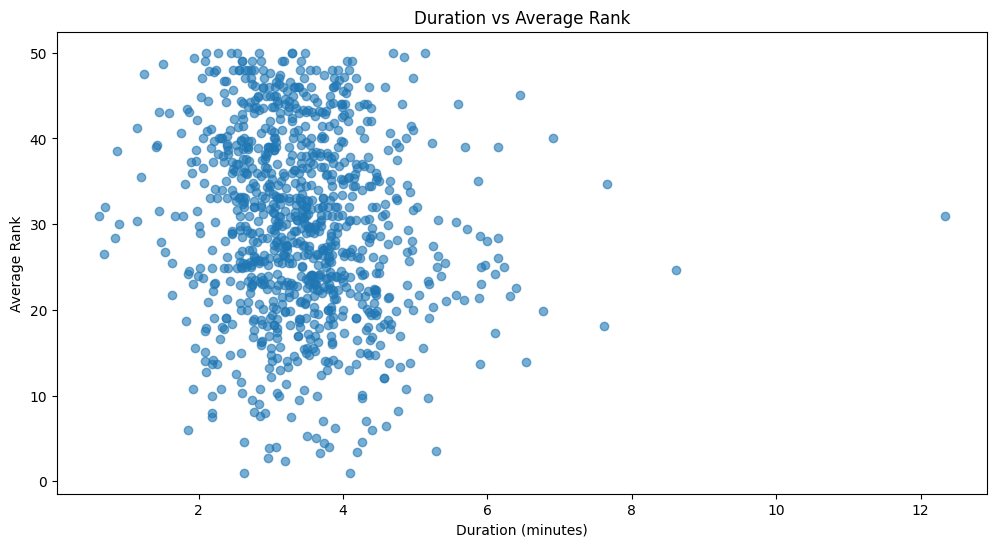

In [56]:
#Song Duration vs Rank
plt.figure(figsize=(12, 6))
plt.scatter(analysis_df['duration_minutes'], analysis_df['avg_rank'], alpha=0.6)
plt.xlabel('Duration (minutes)')
plt.ylabel('Average Rank')
plt.title('Duration vs Average Rank')
plt.show()

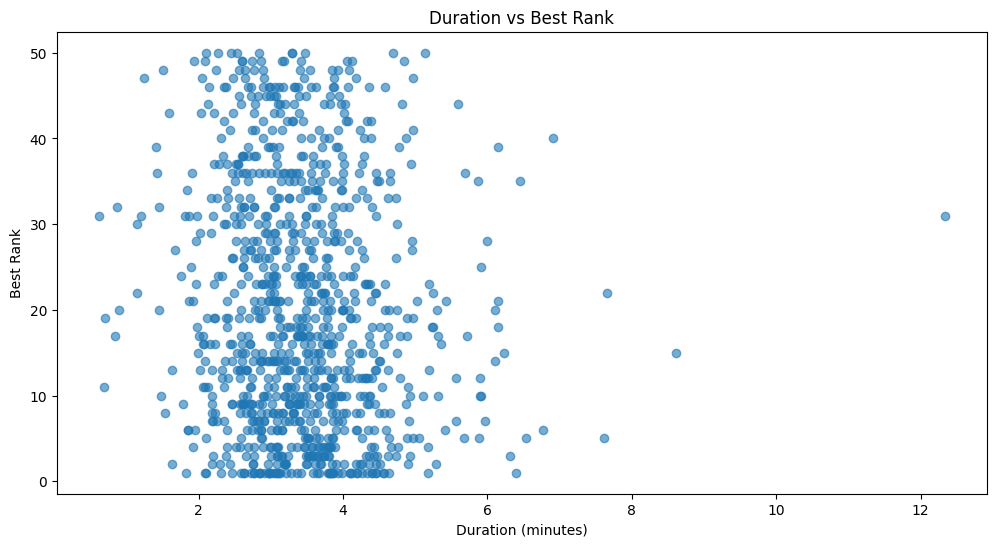

In [57]:
plt.figure(figsize=(12, 6))
plt.scatter(analysis_df['duration_minutes'], analysis_df['best_rank'], alpha=0.6)
plt.xlabel('Duration (minutes)')
plt.ylabel('Best Rank')
plt.title('Duration vs Best Rank')
plt.show()

Songs within the 2–4 minute duration range consistently achieve better peak and average ranks, indicating stronger chart performance. This pattern, combined with higher popularity in the same range, highlights a clear optimal duration window that maximizes both engagement and competitive positioning.



> Songs in the 2–4 minute range dominate both popularity and ranking performance, indicating an optimal duration window.



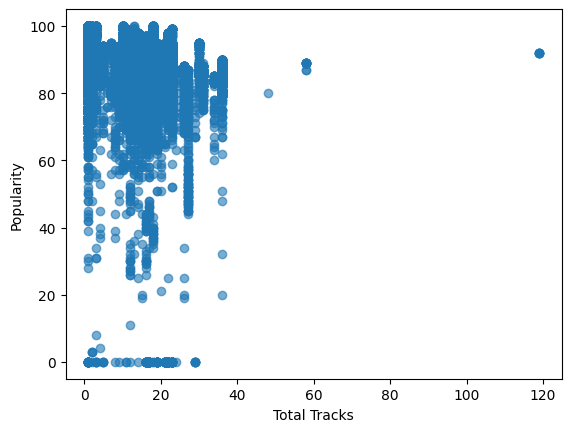

In [58]:
#Album Size vs Song Success
plt.figsize=(12, 6)
plt.scatter(df['total_tracks'],df['popularity'], alpha=0.6)
plt.xlabel('Total Tracks')
plt.ylabel('Popularity')
plt.show()

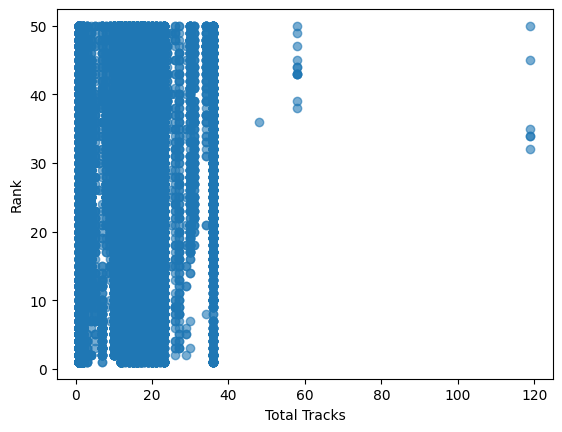

In [59]:
plt.figsize=(12, 6)
plt.scatter(df['total_tracks'], df['position'], alpha=0.6)
plt.xlabel('Total Tracks')
plt.ylabel('Rank')
plt.show()

Album Size of 0-40 show the most concentration for both popularity and rank, depicting the range of album size which is optimal.

#INSIGHTS AND CONCLUSION

The analysis shows that most songs exhibit stable day-to-day rank behavior, with limited fluctuations. Songs entering at higher ranks tend to exit at better positions, indicating a strong advantage of early performance. Fast risers demonstrate strong momentum, while slow decliners maintain extended chart visibility, highlighting different lifecycle patterns.

Only a small number of songs sustain popularity over longer durations, but higher popularity generally correlates with longer chart presence. There is a positive relationship between early success and sustained performance, though chart outcomes also depend on artist dominance, with different artists adopting varied strategies—either multiple entries or a few high-impact tracks.

Most songs on the chart maintain high popularity, with a few outliers achieving short-term high ranks despite lower sustained engagement. Songs in the Top 10 show higher and more consistent popularity, and those with stable popularity tend to exhibit lower rank volatility. Explicit content does not significantly impact performance.

While singles achieve better chart positions, compilation tracks often show relatively high popularity but fail to convert this into strong rankings. Songs in the 2–4 minute duration range dominate both popularity and rank, indicating an optimal duration window. Additionally, album sizes between 0–40 tracks show the highest concentration of successful songs, suggesting an optimal range for album structure.

Overall, to achieve higher ranks and sustained popularity, songs should aim for strong initial entry, maintain consistent engagement, optimize duration within the 2–4 minute range, and leverage strategic release formats such as singles and collaborations. Combining momentum-driven promotion with sustained listener retention and effective artist positioning is key to long-term success on the charts.